# DeepSTARR 数据勘察（M1）

**数据**：`GenerTeam/DeepSTARR-enhancer-activity`（HF 镜像），源自官方 Zenodo 5502060，仅格式调整。果蝇 S2 细胞 STARR-seq，249bp，双任务连续目标（`Dev_log2_enrichment` 发育型 / `Hk_log2_enrichment` 管家型）。

**防泄漏事实（scripts/verify_split.py 已断言）**：train 含 11 条染色体臂，整条 chr2R 臂 held out（valid+test 全部取自 chr2R）；18 条含 N 序列（异染色质臂未测序区）已由 scripts/clean_data.py 过滤。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG = Path('../results/figures')
FIG.mkdir(parents=True, exist_ok=True)
SPLITS = ('train', 'valid', 'test')
COLORS = {'train': '#4878CF', 'valid': '#EE854A', 'test': '#60AC45'}
TARGETS = ('Dev_log2_enrichment', 'Hk_log2_enrichment')

df = {s: pd.read_parquet(f'../data/processed/{s}.parquet') for s in SPLITS}
for s in SPLITS:
    print(f'{s:>6}: {len(df[s]):>8,} 行 | 列: {list(df[s].columns)}')

 train:  402,278 行 | 列: ['id', 'sequence', 'Dev_log2_enrichment', 'Hk_log2_enrichment', 'Dev_log2_enrichment_scaled', 'Hk_log2_enrichment_scaled', 'Dev_log2_enrichment_quantile_normalized', 'Hk_log2_enrichment_quantile_normalized', 'label']
 valid:   40,570 行 | 列: ['id', 'sequence', 'Dev_log2_enrichment', 'Hk_log2_enrichment', 'Dev_log2_enrichment_scaled', 'Hk_log2_enrichment_scaled', 'Dev_log2_enrichment_quantile_normalized', 'Hk_log2_enrichment_quantile_normalized', 'label']
  test:   41,186 行 | 列: ['id', 'sequence', 'Dev_log2_enrichment', 'Hk_log2_enrichment', 'Dev_log2_enrichment_scaled', 'Hk_log2_enrichment_scaled', 'Dev_log2_enrichment_quantile_normalized', 'Hk_log2_enrichment_quantile_normalized', 'label']


## 1. 活性分布（双任务连续目标）

C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2742152443.py:9: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2742152443.py:9: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2742152443.py:9: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2742152443.py:9: UserWarning: Glyph 32946 (\N{CJK UNIFIED IDEOGRAPH-80B2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2742152443.py:9: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2742152443.py:9: UserWarning: Glyph 23500 (\N{CJK 

C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 32946 (\N{CJK UNIFIED IDEOGRAPH-80B2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\

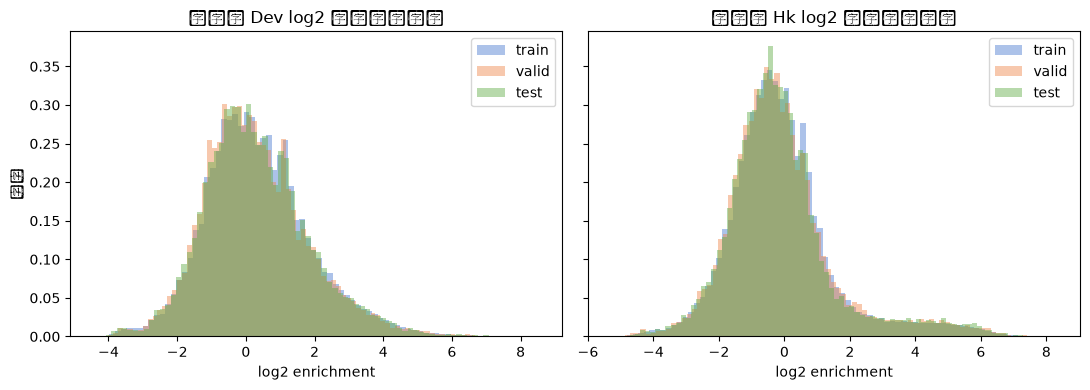

C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 32946 (\N{CJK UNIFIED IDEOGRAPH-80B2}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 22411 (\N{CJK UNI

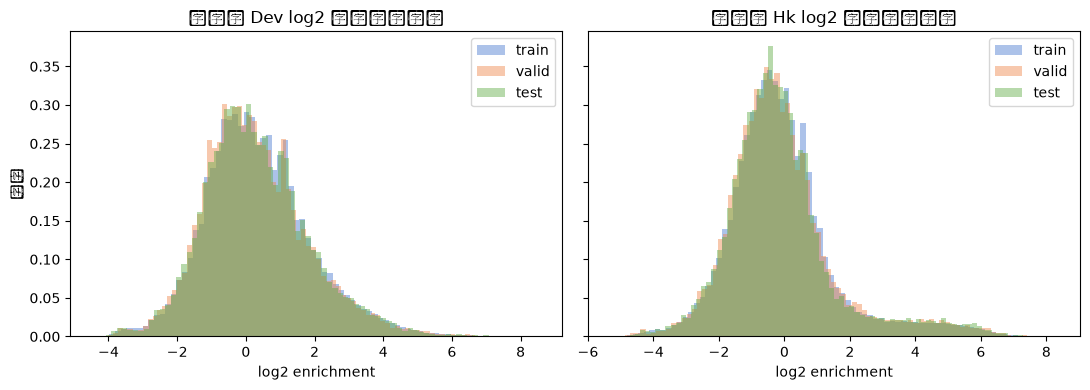

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, name in zip(axes, TARGETS, ('发育型 Dev', '管家型 Hk')):
    for s in SPLITS:
        ax.hist(df[s][col], bins=80, alpha=0.45, density=True, label=s, color=COLORS[s])
    ax.set_title(f'{name} log2 富集倍数分布')
    ax.set_xlabel('log2 enrichment')
    ax.legend()
axes[0].set_ylabel('密度')
fig.tight_layout()
fig.savefig(FIG / '01_activity_dist.png', dpi=130, bbox_inches='tight')
fig

**解读**：两任务活性均右偏（强增强子长尾），train/valid/test 三 split 形状一致——染色体级划分未造成分布漂移。

## 2. 序列长度与 GC 含量

C:\Users\22257\AppData\Local\Temp\ipykernel_17848\999595821.py:12: UserWarning: Glyph 21807 (\N{CJK UNIFIED IDEOGRAPH-552F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\999595821.py:12: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\999595821.py:12: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\999595821.py:12: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\999595821.py:12: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\999595821.py:12: UserWarning: Glyph 24207 (\N{CJK 

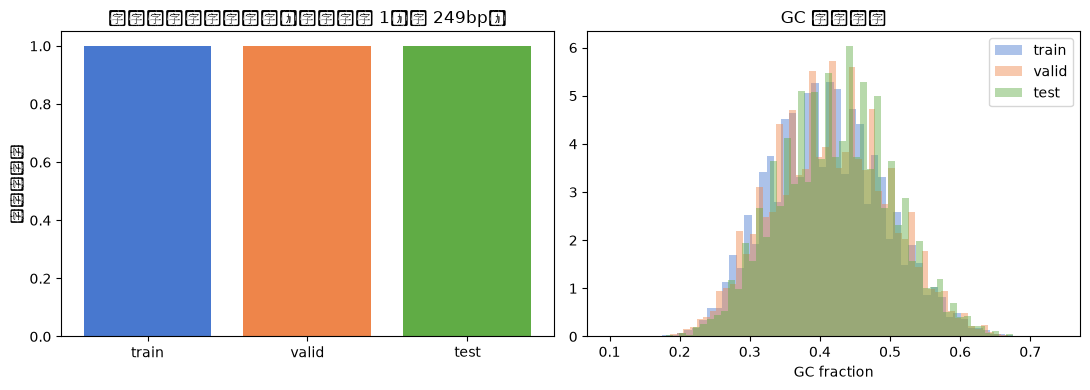

C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 21807 (\N{CJK UNIFIED IDEOGRAPH-552F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 25968 (\N{CJK UNI

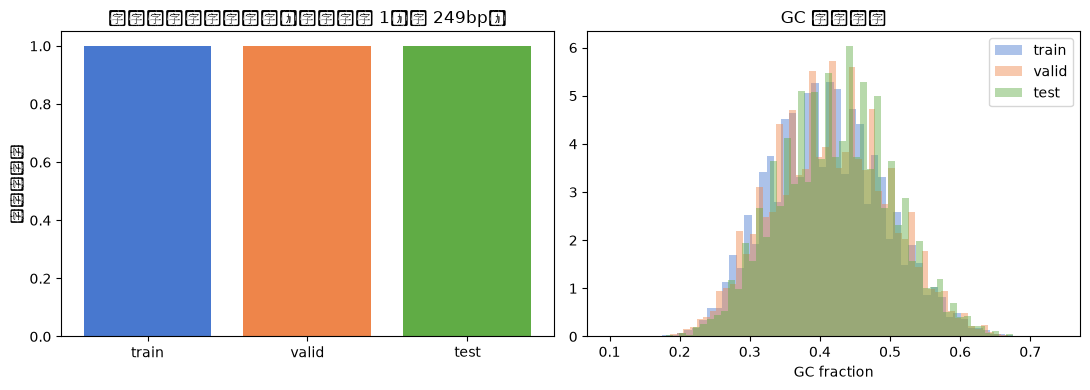

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
lens = {s: df[s]['sequence'].str.len().unique() for s in SPLITS}
axes[0].bar(list(lens), [len(v) for v in lens.values()], color=[COLORS[s] for s in SPLITS])
axes[0].set_title('序列长度唯一值个数（全部应为 1，即 249bp）')
axes[0].set_ylabel('唯一长度数')
for s in SPLITS:
    gc = df[s]['sequence'].str.count('[GC]') / df[s]['sequence'].str.len()
    axes[1].hist(gc, bins=60, alpha=0.45, density=True, label=s, color=COLORS[s])
axes[1].set_title('GC 含量分布')
axes[1].set_xlabel('GC fraction')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / '02_length_gc.png', dpi=130, bbox_inches='tight')
fig

**解读**：长度统一 249bp（每个 split 唯一长度数 = 1）；GC 含量近正态（~45%），split 间一致——k-mer 类 baseline 不会因 GC 偏差占便宜。

## 3. 染色体 × split（防泄漏结构）

C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2002447772.py:13: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2002447772.py:13: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2002447772.py:13: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2002447772.py:13: UserWarning: Glyph 26579 (\N{CJK UNIFIED IDEOGRAPH-67D3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2002447772.py:13: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\2002447772.py:13: UserWarning: Glyph 20307 (\

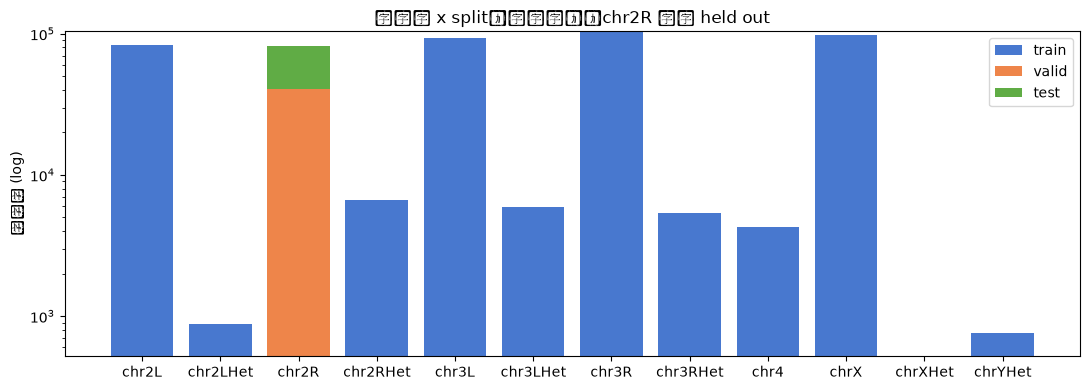

C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 26579 (\N{CJK UNIFIED IDEOGRAPH-67D3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 33394 (\N{CJK UNI

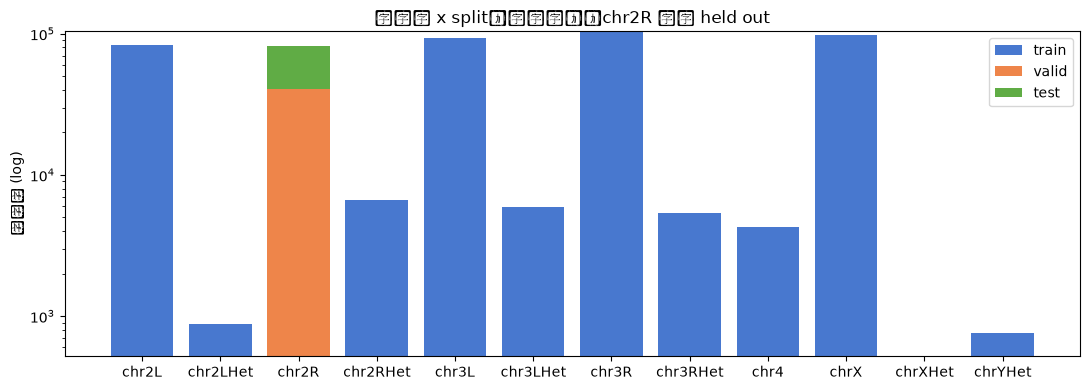

In [4]:
chrom = pd.DataFrame(
    {s: f['id'].str.split('_').str[0].value_counts() for s, f in df.items()}
).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(11, 4))
bottom = np.zeros(len(chrom))
for s in SPLITS:
    ax.bar(chrom.index, chrom[s], bottom=bottom, label=s, color=COLORS[s])
    bottom += chrom[s].to_numpy()
ax.set_yscale('log')
ax.set_title('染色体 x split（对数轴）：chr2R 整臂 held out')
ax.set_ylabel('序列数 (log)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / '03_chr_split.png', dpi=130, bbox_inches='tight')
fig

**解读**：train 覆盖 11 条臂（chr2L/3L/3R/X/4 及异染色质），**chr2R 完整 held out**（valid 40,570 + test 41,186 全部来自 chr2R）——同源序列（>80% 相似）几乎必然落在同臂内，染色体级划分是防泄漏的硬保证。

## 4. Dev 与 Hk 任务相关性

C:\Users\22257\AppData\Local\Temp\ipykernel_17848\1894650949.py:8: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


Pearson r = 0.422


C:\Users\22257\AppData\Local\Temp\ipykernel_17848\1894650949.py:8: UserWarning: Glyph 25277 (\N{CJK UNIFIED IDEOGRAPH-62BD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\1894650949.py:8: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\1894650949.py:8: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\1894650949.py:8: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\1894650949.py:9: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.savefig(FIG / '04_dev_vs_hk.png', dpi=130, bbox_inches='tight')
C:\Users\22257\AppData\Local\Temp\ipykernel_17848\

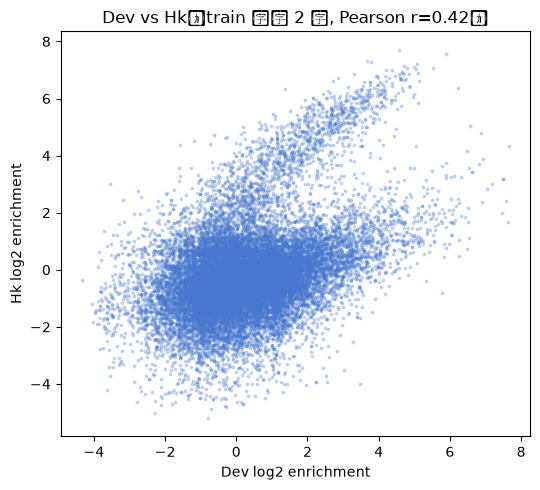

C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 25277 (\N{CJK UNIFIED IDEOGRAPH-62BD}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\22257\Desktop\work\生物信息学\EnhancerScope\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 19975 (\N{CJK UNIFIED IDEOGRAPH-4E07}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


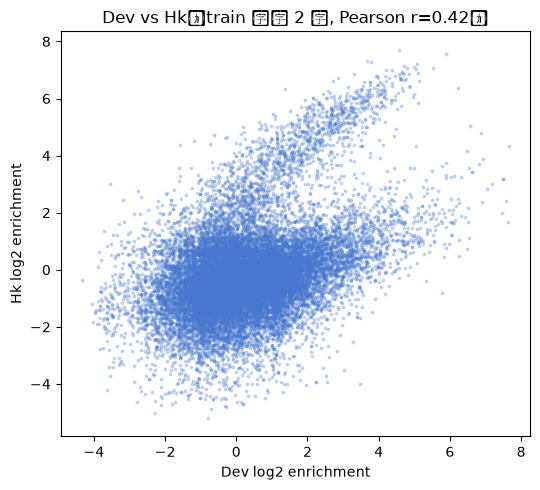

In [5]:
samp = df['train'].sample(20000, random_state=0)
r = samp['Dev_log2_enrichment'].corr(samp['Hk_log2_enrichment'])
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(samp['Dev_log2_enrichment'], samp['Hk_log2_enrichment'], s=3, alpha=0.25, color='#4878CF')
ax.set_xlabel('Dev log2 enrichment')
ax.set_ylabel('Hk log2 enrichment')
ax.set_title(f'Dev vs Hk（train 抽样 2 万, Pearson r={r:.2f}）')
fig.tight_layout()
fig.savefig(FIG / '04_dev_vs_hk.png', dpi=130, bbox_inches='tight')
print(f'Pearson r = {r:.3f}')
fig

**解读**：双任务相关性中等——发育型与管家型增强子共享部分序列语法但各有特异 motif，这正是双头模型（DeepSTARR 式）有意义的依据，也是 M4 可解释性分析的切入点。